In [1]:
import os
import json

import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import numpy as np

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, wilcoxon
from scipy.stats import studentized_range

In [2]:
# get the path of one directory above the actual one an then get the reference to ./output/results

current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
output_dir = os.path.join(current_dir, "output", "results")
print('Current dir:', current_dir)
print('Output dir:', output_dir)

Current dir: /home/moovz/code/Mestrado
Output dir: /home/moovz/code/Mestrado/output/results


In [3]:
# in the output_dir i have subfolders and each one of them contains some .json files that contains the results of the experiments
# i want to read all of the json files and create a pandas dataframe with them to analyze the results
# the columns of the dataframe should be: EDGE_STRATEGY, RANDOM_SEED, DOWN_SAMPLE, N, QB_LINK, GCN_RESULTS, MLP_RESULTS, RF_RESULTS
# notice that GCN_RESULTS, MLP_RESULTS and RF_RESULTS are dictionaries that contains the results of the experiments for each model

target_folders = [
    "CLOSEST-",
    "DELAUNAY",
    "GABRIEL",
    "MST",
    "QB-CLOSEST-",
    "RNG"
]

data = []

# Iterating only through the target folders directly inside output_dir
for folder in target_folders:
    folder_path = os.path.join(output_dir, folder)
    
    # Using "*.json" without recursive=True prevents reading from any subfolders 
    # that might exist inside CLOSEST-, DELAUNAY, etc.
    for json_file in glob(os.path.join(folder_path, "*.json")):
        with open(json_file, "r") as f:
            json_data = json.load(f)
            data.append(json_data)

# now that the json files are loaded i want to create an empty dataframe
df = pd.DataFrame()

# now i eant to set the columns names
columns = ["EDGE_STRATEGY", "RANDOM_SEED", "DOWN_SAMPLE", "N", "QB_LINK", "GCN_RESULTS", "MLP_RESULTS", "RF_RESULTS"]
df = pd.DataFrame(columns=columns)

# now i want to iterate through all of the json files and add the data to the dataframe
for item in data:
    row = {
        "EDGE_STRATEGY": item["config"]["EDGE_STRATEGY"],
        "RANDOM_SEED": item["config"]["RANDOM_SEED"],
        "DOWN_SAMPLE": item["config"]["DOWN_SAMPLE"],
        "N": item["config"]["N"],
        "QB_LINK": item["config"]["QB_LINK"],
        "GCN_RESULTS": item["best_gcn_results"],
        "MLP_RESULTS": item["mlp_results"],
        "RF_RESULTS": item["rf_results"]
    }
    # now add this row to the dataframe
    df.loc[len(df)] = row

df.tail()

,EDGE_STRATEGY,RANDOM_SEED,DOWN_SAMPLE,N,QB_LINK,GCN_RESULTS,MLP_RESULTS,RF_RESULTS
169,RNG,24,False,2,False,"{'Rush': {'precision': 0.733264675592173, 'rec...","{'Rush': {'precision': 0.6, 'recall': 0.612445...","{'Rush': {'precision': 0.6777041942604857, 're..."
170,RNG,27,False,2,False,"{'Rush': {'precision': 0.7579214195183777, 're...","{'Rush': {'precision': 0.6111696522655427, 're...","{'Rush': {'precision': 0.7002212389380531, 're..."
171,RNG,9,False,2,False,"{'Rush': {'precision': 0.7569367369589345, 're...","{'Rush': {'precision': 0.5979591836734693, 're...","{'Rush': {'precision': 0.6759156492785794, 're..."
172,RNG,26,False,2,False,"{'Rush': {'precision': 0.7221644120707597, 're...","{'Rush': {'precision': 0.6017316017316018, 're...","{'Rush': {'precision': 0.6761800219538968, 're..."
173,RNG,16,False,2,False,"{'Rush': {'precision': 0.7250996015936255, 're...","{'Rush': {'precision': 0.6212952799121844, 're...","{'Rush': {'precision': 0.6903669724770642, 're..."


In [4]:
# Extract macro avg f1-score for each model
df['GCN_F1'] = df['GCN_RESULTS'].apply(lambda x: x['macro avg']['f1-score'])
df['MLP_F1'] = df['MLP_RESULTS'].apply(lambda x: x['macro avg']['f1-score'])
df['RF_F1'] = df['RF_RESULTS'].apply(lambda x: x['macro avg']['f1-score'])

# Group by edge strategy and compute max/mean
summary = df.groupby('EDGE_STRATEGY').agg(
    GCN_Max=('GCN_F1', 'max'),
    GCN_Mean=('GCN_F1', 'mean'),
    MLP_Max=('MLP_F1', 'max'),
    MLP_Mean=('MLP_F1', 'mean'),
    RF_Max=('RF_F1', 'max'),
    RF_Mean=('RF_F1', 'mean'),
).round(4)

# Clean up strategy names for display (remove trailing "-")
summary.index = summary.index.str.rstrip('-')

# Find the global max across all Max columns and all Mean columns
max_cols = ['GCN_Max', 'MLP_Max', 'RF_Max']
mean_cols = ['GCN_Mean', 'MLP_Mean', 'RF_Mean']

global_max = summary[max_cols].max().max()
global_mean = summary[mean_cols].max().max()

def fmt(val, global_best):
    if val == global_best:
        return f"\\textbf{{{val:.4f}}}"
    return f"{val:.4f}"

# Generate LaTeX
rows = []
for strategy, row in summary.iterrows():
    rows.append(
        f"            \\textbf{{{strategy}}} & {fmt(row['GCN_Max'], global_max)} & {fmt(row['GCN_Mean'], global_mean)} "
        f"& {fmt(row['MLP_Max'], global_max)} & {fmt(row['MLP_Mean'], global_mean)} "
        f"& {fmt(row['RF_Max'], global_max)} & {fmt(row['RF_Mean'], global_mean)} \\\\"
    )

latex = r"""\begin{table*}[h!]
    \centering
    \label{tab:f1_score_results}
    \resizebox{\textwidth}{!}{ 
        \begin{tabular}{l ccc ccc c}
            \toprule
            & \multicolumn{2}{c}{\textbf{GNN}} & \multicolumn{2}{c}{\textbf{MLP}} & \multicolumn{2}{c}{\textbf{RF}} \\
            \textbf{Edge Strategy} & \textbf{Max} & \textbf{Mean} & \textbf{Max} & \textbf{Mean} & \textbf{Max} & \textbf{Mean} \\
            \midrule
""" + "\n".join(rows) + r"""
            \bottomrule
        \end{tabular}
    }
    \caption{Performance Results (F1-Score) by Graph Strategy and Model Architecture}
\end{table*}"""

print(latex)

\begin{table*}[h!]
    \centering
    \label{tab:f1_score_results}
    \resizebox{\textwidth}{!}{ 
        \begin{tabular}{l ccc ccc c}
            \toprule
            & \multicolumn{2}{c}{\textbf{GNN}} & \multicolumn{2}{c}{\textbf{MLP}} & \multicolumn{2}{c}{\textbf{RF}} \\
            \textbf{Edge Strategy} & \textbf{Max} & \textbf{Mean} & \textbf{Max} & \textbf{Mean} & \textbf{Max} & \textbf{Mean} \\
            \midrule
            \textbf{CLOSEST} & 0.7995 & 0.7812 & 0.6954 & 0.6766 & 0.7492 & 0.7319 \\
            \textbf{DELAUNAY} & 0.7850 & 0.7628 & 0.7039 & 0.6795 & 0.7492 & 0.7319 \\
            \textbf{GABRIEL} & 0.7922 & 0.7731 & 0.6925 & 0.6778 & 0.7492 & 0.7319 \\
            \textbf{MST} & 0.8138 & \textbf{0.7925} & 0.7033 & 0.6790 & 0.7492 & 0.7319 \\
            \textbf{QB-CLOSEST} & 0.7935 & 0.7720 & 0.6966 & 0.6784 & 0.7492 & 0.7319 \\
            \textbf{RNG} & \textbf{0.8158} & 0.7916 & 0.6958 & 0.6795 & 0.7492 & 0.7319 \\
            \bottomrule
        \end{tabul

In [5]:
# Check RF and MLP results across runs within each strategy
for strategy in df['EDGE_STRATEGY'].unique():
    subset = df[df['EDGE_STRATEGY'] == strategy]
    rf_same = subset['RF_F1'].nunique() == 1
    mlp_same = subset['MLP_F1'].nunique() == 1
    print(f"{strategy}: RF all same = {rf_same}, MLP all same = {mlp_same}")
    print(f"  RF  - Min: {subset['RF_F1'].min():.4f}, Max: {subset['RF_F1'].max():.4f}, Mean: {subset['RF_F1'].mean():.4f}")
    print(f"  MLP - Min: {subset['MLP_F1'].min():.4f}, Max: {subset['MLP_F1'].max():.4f}, Mean: {subset['MLP_F1'].mean():.4f}")
    print()

CLOSEST-: RF all same = False, MLP all same = False
  RF  - Min: 0.7184, Max: 0.7492, Mean: 0.7319
  MLP - Min: 0.6586, Max: 0.6954, Mean: 0.6766

DELAUNAY: RF all same = False, MLP all same = False
  RF  - Min: 0.7184, Max: 0.7492, Mean: 0.7319
  MLP - Min: 0.6572, Max: 0.7039, Mean: 0.6795

GABRIEL: RF all same = False, MLP all same = False
  RF  - Min: 0.7184, Max: 0.7492, Mean: 0.7319
  MLP - Min: 0.6609, Max: 0.6925, Mean: 0.6778

MST: RF all same = False, MLP all same = False
  RF  - Min: 0.7184, Max: 0.7492, Mean: 0.7319
  MLP - Min: 0.6656, Max: 0.7033, Mean: 0.6790

QB-CLOSEST-: RF all same = False, MLP all same = False
  RF  - Min: 0.7184, Max: 0.7492, Mean: 0.7319
  MLP - Min: 0.6597, Max: 0.6966, Mean: 0.6784

RNG: RF all same = False, MLP all same = False
  RF  - Min: 0.7184, Max: 0.7492, Mean: 0.7319
  MLP - Min: 0.6607, Max: 0.6958, Mean: 0.6795



In [6]:
FONT_SIZE = 18

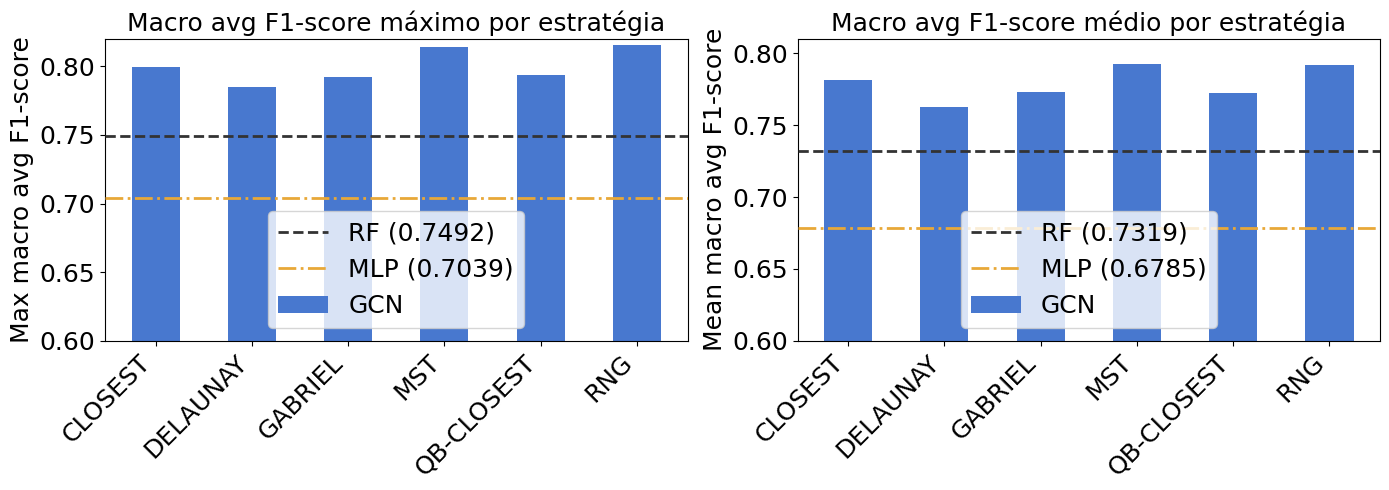

In [10]:
# Figure 1: Max and Mean F1-Score per Edge Strategy
# GCN as bars, MLP and RF as horizontal lines (constant across strategies)

# Since MLP and RF don't vary by edge strategy, get their single values
mlp_max_val = summary['MLP_Max'].max()  # all the same
mlp_mean_val = summary['MLP_Mean'].mean()
rf_max_val = summary['RF_Max'].max()
rf_mean_val = summary['RF_Mean'].mean()

strategies = summary.index.tolist()
x = np.arange(len(strategies))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Max ---
axes[0].bar(x, summary['GCN_Max'].values, width=0.5, color='#4878CF', label='GCN', zorder=2)
axes[0].axhline(y=rf_max_val, color='#333333', linestyle='--', linewidth=2, label=f'RF ({rf_max_val:.4f})', zorder=3)
axes[0].axhline(y=mlp_max_val, color='#E8A838', linestyle='-.', linewidth=2, label=f'MLP ({mlp_max_val:.4f})', zorder=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(strategies, rotation=45, ha='right', fontsize=FONT_SIZE)
axes[0].set_ylabel('Max macro avg F1-score', fontsize=FONT_SIZE)
axes[0].set_title('Macro avg F1-score máximo por estratégia', fontsize=FONT_SIZE)
axes[0].legend(fontsize=FONT_SIZE, loc='lower center')
axes[0].tick_params(axis='y', labelsize=FONT_SIZE)
axes[0].set_ylim(0.6, 0.82)

# --- Right: Mean ---
axes[1].bar(x, summary['GCN_Mean'].values, width=0.5, color='#4878CF', label='GCN', zorder=2)
axes[1].axhline(y=rf_mean_val, color='#333333', linestyle='--', linewidth=2, label=f'RF ({rf_mean_val:.4f})', zorder=3)
axes[1].axhline(y=mlp_mean_val, color='#E8A838', linestyle='-.', linewidth=2, label=f'MLP ({mlp_mean_val:.4f})', zorder=3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(strategies, rotation=45, ha='right', fontsize=FONT_SIZE)
axes[1].set_ylabel('Mean macro avg F1-score', fontsize=FONT_SIZE)
axes[1].set_title('Macro avg F1-score médio por estratégia', fontsize=FONT_SIZE)
axes[1].legend(fontsize=FONT_SIZE, loc='lower center')
axes[1].tick_params(axis='y', labelsize=FONT_SIZE)
axes[1].set_ylim(0.6, 0.81)

plt.tight_layout()
plt.savefig('../output/fig1_gcn_vs_baselines.png', dpi=300, bbox_inches='tight')
plt.show()

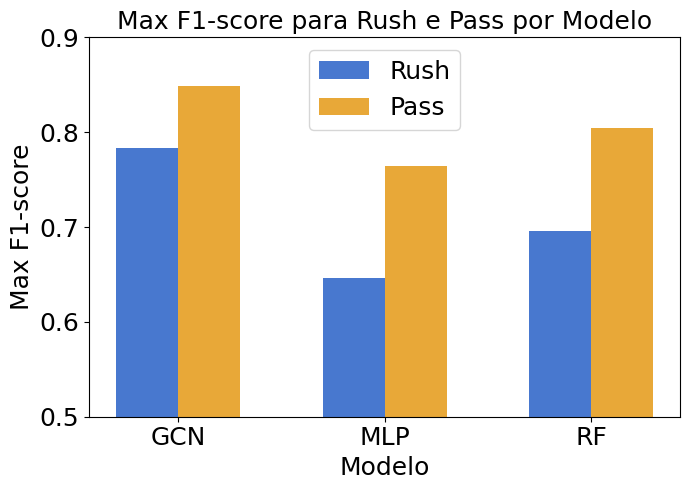

In [11]:
# Figure 2: Max F1-score for Rush and Pass per model

# Extract per-class f1-scores
df['GCN_Rush_F1'] = df['GCN_RESULTS'].apply(lambda x: x['Rush']['f1-score'])
df['GCN_Pass_F1'] = df['GCN_RESULTS'].apply(lambda x: x['Pass']['f1-score'])
df['MLP_Rush_F1'] = df['MLP_RESULTS'].apply(lambda x: x['Rush']['f1-score'])
df['MLP_Pass_F1'] = df['MLP_RESULTS'].apply(lambda x: x['Pass']['f1-score'])
df['RF_Rush_F1'] = df['RF_RESULTS'].apply(lambda x: x['Rush']['f1-score'])
df['RF_Pass_F1'] = df['RF_RESULTS'].apply(lambda x: x['Pass']['f1-score'])

# Get the max f1-score across all runs and strategies for each model/class
models = ['GCN', 'MLP', 'RF']
rush_max = [df['GCN_Rush_F1'].max(), df['MLP_Rush_F1'].max(), df['RF_Rush_F1'].max()]
pass_max = [df['GCN_Pass_F1'].max(), df['MLP_Pass_F1'].max(), df['RF_Pass_F1'].max()]

x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, rush_max, width, color='#4878CF', label='Rush')
ax.bar(x + width/2, pass_max, width, color='#E8A838', label='Pass')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=FONT_SIZE)
ax.set_xlabel('Modelo', fontsize=FONT_SIZE)
ax.set_ylabel('Max F1-score', fontsize=FONT_SIZE)
ax.set_title('Max F1-score para Rush e Pass por Modelo', fontsize=FONT_SIZE)
ax.legend(fontsize=FONT_SIZE)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
ax.set_ylim(0.5, 0.9)

plt.tight_layout()
plt.savefig('../output/fig2_rush_vs_pass.png', dpi=300, bbox_inches='tight')
plt.show()

Number of blocks: 29
Treatments: ['GCN-CLOSEST', 'GCN-DELAUNAY', 'GCN-GABRIEL', 'GCN-MST', 'GCN-QB-CLOSEST', 'GCN-RNG', 'MLP', 'RF']

Friedman test: statistic=174.3448, p-value=3.043e-34

Mean Ranks:
GCN-RNG           1.689655
GCN-MST           1.827586
GCN-CLOSEST       3.241379
GCN-GABRIEL       4.103448
GCN-QB-CLOSEST    4.655172
GCN-DELAUNAY      5.551724
RF                6.931034
MLP               8.000000
dtype: float64

Nemenyi p-values:
                GCN-CLOSEST  GCN-DELAUNAY  GCN-GABRIEL  GCN-MST  \
GCN-CLOSEST          1.0000        0.0079       0.8836   0.3529   
GCN-DELAUNAY         0.0079        1.0000       0.3210   0.0000   
GCN-GABRIEL          0.8836        0.3210       1.0000   0.0096   
GCN-MST              0.3529        0.0000       0.0096   1.0000   
GCN-QB-CLOSEST       0.3529        0.8605       0.9896   0.0003   
GCN-RNG              0.2352        0.0000       0.0043   1.0000   
MLP                  0.0000        0.0035       0.0000   0.0000   
RF            

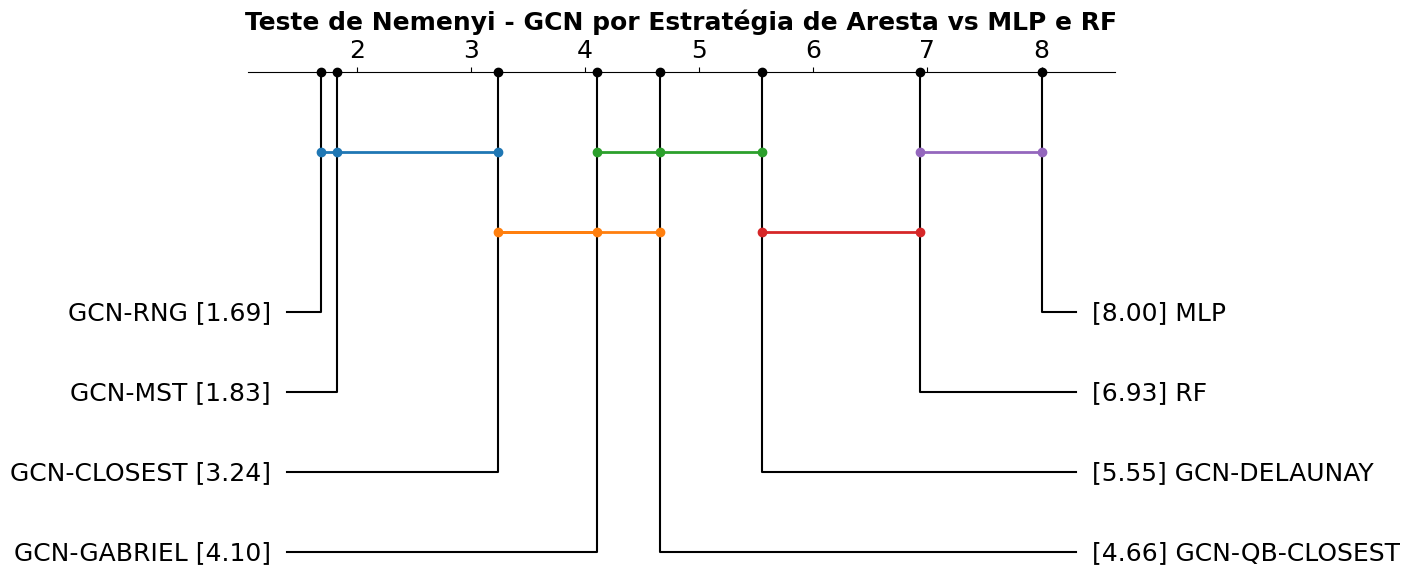

In [12]:
# Nemenyi test: each GCN edge strategy individually vs MLP and RF
# Block = (RANDOM_SEED, DOWN_SAMPLE, QB_LINK, N)
# Treatments = GCN-CLOSEST, GCN-DELAUNAY, GCN-GABRIEL, GCN-MST, GCN-QB-CLOSEST, GCN-RNG, MLP, RF

# Pivot GCN results: one column per edge strategy
gcn_pivot = df.pivot_table(
    index=['RANDOM_SEED', 'DOWN_SAMPLE', 'QB_LINK', 'N'],
    columns='EDGE_STRATEGY',
    values='GCN_F1'
)
gcn_pivot.columns = ['GCN-' + col.rstrip('-') for col in gcn_pivot.columns]

# MLP and RF are constant across edge strategies per block, so take the mean
mlp_pivot = df.groupby(['RANDOM_SEED', 'DOWN_SAMPLE', 'QB_LINK', 'N'])['MLP_F1'].mean()
rf_pivot = df.groupby(['RANDOM_SEED', 'DOWN_SAMPLE', 'QB_LINK', 'N'])['RF_F1'].mean()

# Combine into a single table
pivot_table = gcn_pivot.copy()
pivot_table['MLP'] = mlp_pivot
pivot_table['RF'] = rf_pivot
pivot_table.dropna(inplace=True)

print(f"Number of blocks: {len(pivot_table)}")
print(f"Treatments: {list(pivot_table.columns)}")

# Friedman test
stat, p_value = friedmanchisquare(*[pivot_table[col] for col in pivot_table.columns])
print(f"\nFriedman test: statistic={stat:.4f}, p-value={p_value:.4g}")

# Mean ranks
mean_ranks = pivot_table.rank(axis=1, ascending=False).mean().sort_values()
print(f"\nMean Ranks:\n{mean_ranks}")

# Nemenyi post-hoc + CD diagram
fig, ax = plt.subplots(figsize=(14, 6))

if p_value < 0.05:
    nemenyi_results = sp.posthoc_nemenyi_friedman(pivot_table.to_numpy())
    nemenyi_results.columns = pivot_table.columns
    nemenyi_results.index = pivot_table.columns
    print(f"\nNemenyi p-values:")
    print(nemenyi_results.round(4))

    sp.critical_difference_diagram(
        ranks=mean_ranks,
        sig_matrix=nemenyi_results,
        label_fmt_left='{label} [{rank:.2f}]  ',
        label_fmt_right='  [{rank:.2f}] {label}',
        text_h_margin=0.3,
        crossbar_props={'color': None, 'marker': 'o'},
        elbow_props={'color': 'black'},
        ax=ax
    )
    ax.set_title('Teste de Nemenyi - GCN por Estratégia de Aresta vs MLP e RF', fontsize=FONT_SIZE, fontweight='bold')
    # Update all text elements to FONT_SIZE
    for text in ax.texts:
        text.set_fontsize(FONT_SIZE)
    ax.tick_params(axis='x', labelsize=FONT_SIZE)
else:
    ax.text(0.5, 0.5, f"Teste de Friedman não significativo (p={p_value:.4f})",
            ha='center', va='center', fontsize=FONT_SIZE)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../output/nemenyi_gcn_strategies_vs_baselines.png', dpi=300, bbox_inches='tight')
plt.show()